# Semana 4: Filas

En la siguiente celda de código se incluye el script correspondiente al **Fragametno de Código 6.6 y 6.7**.

In [14]:
class Empty(Exception):
    pass

class ArrayQueue:
    """FIFO queue implementation using a Python list as underlying storage."""
    DEFAULT_CAPACITY = 10  # moderate capacity for all new queues

    def __init__(self):
        """Create an empty queue."""
        self._data = [None] * ArrayQueue.DEFAULT_CAPACITY
        self._size = 0
        self._front = 0

    def __len__(self):
        """Return the number of elements in the queue."""
        return self._size

    def is_empty(self):
        """Return True if the queue is empty."""
        return self._size == 0

    def first(self):
        """Return (but do not remove) the element at the front of the queue.
        Raise Empty exception if the queue is empty.
        """
        if self.is_empty():
            raise Empty('Queue is empty')
        return self._data[self._front]

    def dequeue(self):
        """Remove and return the first element of the queue (i.e., FIFO).
        Raise Empty exception if the queue is empty.
        """
        if self.is_empty():
            raise Empty('Queue is empty')
        answer = self._data[self._front]
        self._data[self._front] = None          # help garbage collection
        self._front = (self._front + 1) % len(self._data)
        self._size = self._size - 1
        return answer

    def enqueue(self, e):
        """Add an element to the back of queue."""
        if self._size == len(self._data):
            self._resize(2 * len(self._data))   # double the array size
        avail = (self._front + self._size) % len(self._data)
        self._data[avail] = e
        self._size += 1

    def _resize(self, cap):
        """Resize to a new list of capacity >= len(self)."""
        old = self._data                         # keep track of existing list
        self._data = [None] * cap                # allocate list with new capacity
        walk = self._front
        for k in range(self._size):              # only consider existing elements
            self._data[k] = old[walk]            # intentionally shift indices
            walk = (walk + 1) % len(old)        # use old size as modulus
        self._front = 0                          # front has been
    
    def show_stack(self):
        if self._data == 0:
            raise Empty("Empty list")
        print(self._data)

**R-6.7** What values are returned during the following sequence of queue operations, if executed on an initially empty queue? enqueue(5), enqueue(3), dequeue(), enqueue(2), enqueue(8), dequeue(), dequeue(), enqueue(9), enqueue(1), dequeue(), enqueue(7), enqueue(6), dequeue(), dequeue(), enqueue(4), dequeue(), dequeue().

|            | return |  stack  |
| ---------  | -------| ------- |
| enqueue(5) |        |    [5,N,N,N,N,N,N,N,N,N]
|enqueue(3)  |        |    [5,3,N,N,N,N,N,N,N,N]  
|dequeue(),  |  5      |    [N,3,N,N,N,N,N,N,N,N]
|enqueue(2), |         |    [N,3,2,N,N,N,N,N,N,N]
|enqueue(8), |         |    [N,3,2,8,N,N,N,N,N,N]
|dequeue(),  |    3     |    [N,N,2,8,N,N,N,N,N,N]    
|dequeue(),  |    2     |    [N,N,N,8,N,N,N,N,N,N]
|enqueue(9), |         |    [N,N,N,8,9,N,N,N,N,N]
|enqueue(1), |         |    [N,N,N,8,9,1,N,N,N,N]
|dequeue(),  |     8    |    [N,N,N,N,9,1,N,N,N,N]
|enqueue(7), |         |    [N,N,N,N,9,1,7,N,N,N]
|enqueue(6), |         |    [N,N,N,N,9,1,7,6,N,N]
|dequeue(),  |     9    |    [N,N,N,N,N,1,7,6,N,N]
|dequeue(),  |      1   |    [N,N,N,N,N,N,7,6,N,N]
|enqueue(4), |         |    [N,N,N,N,N,N,7,6,4,N]
|dequeue(),  |    7     |    [N,N,N,N,N,N,N,6,4,N]
|dequeue().  |       6  |    [N,N,N,N,N,N,N,N,4,N]



**R-6.8** Suppose an initially empty queue $Q$ has executed a total of 32 enqueue operations, 10 first operations, and 15 dequeue operations, 5 of which raised Empty errors that were caught and ignored. What is the current size of $Q$?

First you have 32 numbers on the list, then it tells you that shows you the initial number 10 times wich we won't use for determine the size of the list. Then you delete the first 15 numbers but 5 of those deletes raised Empty errores so we erased them, we have  $ 32 - 10 = 22 $

**R-6.10** Consider what happens if the loop in the ArrayQueue._resize method at lines 53–55 of Code Fragment 6.7 had been implemented as:

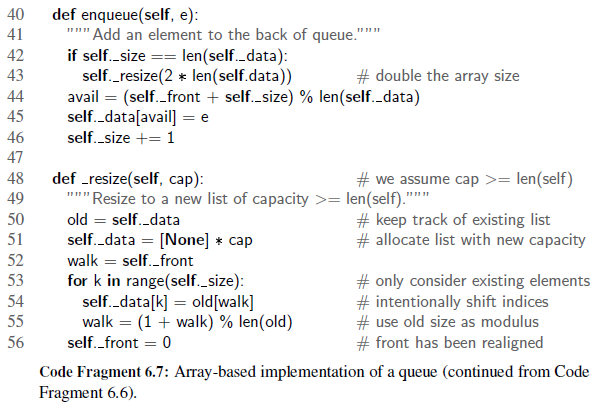

In [ ]:
for k in range(self._size):
    self._data[k] = old[k]    # rather than old[walk]

Give a clear explanation of what could go wrong.

Lo que ocurre es que primero se guarda la lista vieja en old, es entonces que creamos una lista vacía con nueva capacidad. Después guardamos el primer valor de lista. Entramos al ciclo de la lista vacía, donde iterará desde 0 hasta su rango, pero como está vacía, llamamos a la lista vieja con old[walk] y adentro le metemos el valor del front, entonces esto se irá guardando en cada valor de cada iteración del for. Este walk irá incrementando dentro del rango de la lista con walk = (1+walk) % len(old) para que vaya tomando el siguiente valor dentro de la lista. Al poner old[k], solo está tomando los valores de self._size y este último es simplemente la cantidad de valores que hay en la lista, nunca se accede a ningún valor real de self._data. Esto es lo que sucede si lo cambiamos.

**R-6.12** What values are returned during the following sequence of deque ADT operations, on initially empty deque? add_first(4), add_last(8), add_last(9), add_first(5), back(), delete_first(), delete_last(), add_last(7), first(), last(), add_last(6), delete_first(), delete_last().

|              | return |  stack  |
| ---------   | -------| ------- |
| add_first(4) |        |    [4,N,N,N,N,N,N,N,N,N]
|add_last(8)  |        |    [4,8,N,N,N,N,N,N,N,N]  
|add_last(9),  |       |    [4,8,9,N,N,N,N,N,N,N]
|add_first(5), |         |    [4,8,9,N,N,N,N,N,N,5]
|last()         |    9    |    [4,8,9,N,N,N,N,N,N,5]
|delete_first(),  |    5     |    [4,8,9,N,N,N,N,N,N,N]
|delete_last(),  |    9    |    [4,8,N,N,N,N,N,N,N,N]
|add_last(7),  |         |    [4,8,7,N,N,N,N,N,N,N]  
|first(),       |    4    |    [4,8,7,N,N,N,N,N,N,N]  
|last(),        |     7   |    [4,8,7,N,N,N,N,N,N,N]   
|add_last(6),     |         |    [4,8,7,6,N,N,N,N,N,N]   
|delete_first(), |       4   |   [N,8,7,6,N,N,N,N,N,N]  


**R-6.13** Suppose you have a deque $D$ containing the numbers (1, 2, 3, 4, 5, 6, 7, 8), in this order. Suppose further that you have an initially empty queue $Q$. Give a code fragment that uses only $D$ and $Q$ (and no other variables) and results in $D$ storing the elements in the order (1, 2, 3, 5, 4, 6, 7, 8).

In [ ]:
class ArrayDeque:
    """FIFO queue implementation using a Python list as underlying storage."""
      # moderate capacity for all new queues

    DEFAULT_CAPACITY = 8
    def __init__(self):
        """Create an empty queue."""
        self._data = [None] * ArrayDeque.DEFAULT_CAPACITY
        self._size = 0
        self._front = 0

    def __len__(self):
        """Return the number of elements in the queue."""
        return self._size

    def is_empty(self):
        """Return True if the queue is empty."""
        return self._size == 0

    def first(self):
        """Return (but do not remove) the element at the front of the queue.
        Raise Empty exception if the queue is empty.
        """
        if self.is_empty():
            raise Empty('Queue is empty')
        return self._data[self._front]
    
    def last(self):
            return self._data(self._front+self._size-1) % len(self._data)

    def delete_first(self):
        """Remove and return the first element of the queue (i.e., FIFO).
        Raise Empty exception if the queue is empty.
        """
        if self.is_empty():
            raise Empty('Queue is empty')
        answer = self._data[self._front]
        self._data[self._front] = None     
        self._front = (self._front + 1) % len(self._data)
        self._size = self._size - 1
        return answer
    
    def delete_last(self):
            if self.is_empty():
                raise Empty('Queue is empty')
            avail = (self._front + self._size - 1) % len(self._data)
            answer = self._data[avail]
            self._data[avail] = None          
            self._size = self._size - 1
            
            
            return answer

    def add_first(self, e):
        """Add an element to the back of queue."""
        if self._size == len(self._data):
            self._resize(2 * len(self._data))   # double the array size
        avail = (self._front - 1) % len(self._data)
        self._data[avail] = e
        self._size += 1
        self._front = avail # El nuevo elemento que agregamos en add first se convierte en el primero
        
        
    def add_last(self, e):
            """Add an element to the right of deque."""
            if self._size == len(self._data):
                self._resize(2 * len(self._data))   # double the array size
            avail = (self._front + self._size) % len(self._data)
            self._data[avail] = e
            self._size += 1


    def _resize(self, cap):
        """Resize to a new list of capacity >= len(self)."""
        old = self._data                         # keep track of existing list
        self._data = [None] * cap                # allocate list with new capacity
        walk = self._front
        for k in range(self._size):              # only consider existing elements
            self._data[k] = old[walk]            # intentionally shift indices
            walk = (walk + 1) % len(old)        # use old size as modulus
        self._front = 0                          # front has been
        
    def show_stack(self):
        if self._data == 0:
            print("Empty list")
        print(self._data)
    
    

In [30]:
Q = ArrayQueue()
D = ArrayDeque()

D.add_first(5)
D.add_first(3)
D.add_first(2)
D.add_first(1)
D.add_last(4)
D.add_last(6)
D.add_last(7)
D.add_last(8)

D._resize(10)
D.show_stack()

[1, 2, 3, 5, 4, 6, 7, 8, None, None]


**R-6.14** Repeat the previous problem using the deque $D$ and an initially empty stack $S$.

In [37]:
class Empty(Exception):
    """Error attempting to access an element from an empty container."""
    pass

class ArrayStack:
    """LIFO Stack implementation using a Python list as underlying storage."""

    def __init__(self):
        """Create an empty stack."""
        self._data = []  # nonpublic list instance

    def __len__(self):
        """Return the number of elements in the stack."""
        return len(self._data)

    def is_empty(self):
        """Return True if the stack is empty."""
        return len(self._data) == 0

    def push(self, e):
        """Add element e to the top of the stack."""
        self._data.append(e)  # new item stored at end of list

    def top(self):
        """Return (but do not remove) the element at the top of the stack.
        Raise Empty exception if the stack is empty.
        """
        if self.is_empty():
            raise Empty('Stack is empty')
        return self._data[-1]  # the last item in the list

    def pop(self):
        """Remove and return the element from the top of the stack (i.e., LIFO).
        Raise Empty exception if the stack is empty.
        """
        if self.is_empty():
            raise Empty('Stack is empty')
        return self._data.pop()  # remove last

In [41]:
Q = ArrayQueue()
D = ArrayDeque()

S = ArrayStack()
for i in [1, 2, 3, 4, 5, 6, 7, 8]:
    D.add_last(i)
D.add_last(D.delete_first())

D.add_last(D.delete_first())
D.add_last(D.delete_first())
S.push(D.delete_first())
D.add_last(D.delete_first())
D.add_last(S.pop())
D.add_last(D.delete_first())
D.add_last(D.delete_first())
D.add_last(D.delete_first())
D.show_stack()

[1, 2, 3, 5, 4, 6, 7, 8]
